# Gaussian Naive Bayes — Simple Numeric Example

## Predicting Student Pass or Fail

Inputs:
- StudyHours
- AttendancePercent

Target:
- Pass
- Fail

We use `GaussianNB` because the input features are continuous numeric values.


## 1. Import libraries

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

## 2. Load data

In [7]:
df = pd.read_csv("student_pass_naive_bayes.csv")
df.head()

,StudyHours,AttendancePercent,Result
0,4.8,92,Pass
1,4.0,71,Fail
2,5.4,66,Pass
3,8.1,51,Pass
4,3.2,66,Fail


## 3. Explore data

In [3]:
print(df.shape)
print(df.isnull().sum())
print(df["Result"].value_counts())
display(df.describe())

(120, 3)
StudyHours           0
AttendancePercent    0
Result               0
dtype: int64
Result
Pass    69
Fail    51
Name: count, dtype: int64


,StudyHours,AttendancePercent
count,120.000000,120.000000
mean,5.125000,71.841667
std,2.584383,16.267716
min,0.600000,46.000000
25%,2.900000,57.000000
50%,4.800000,69.000000
75%,7.625000,88.000000
max,9.900000,99.000000


## 4. Visualize classes

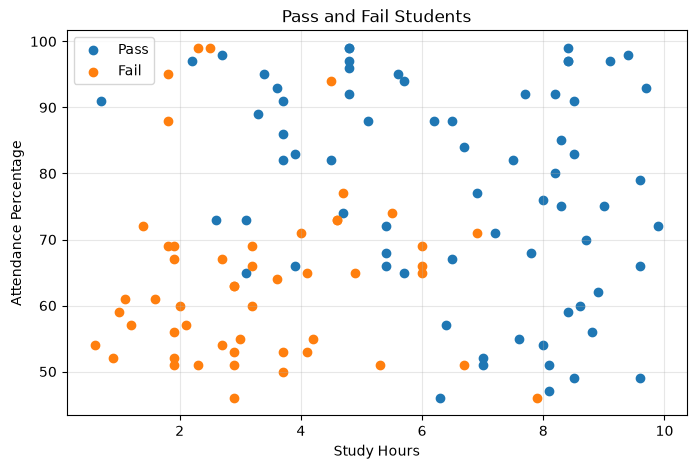

In [15]:
plt.figure(figsize=(8, 5))

for label in df['Result'].unique():
    stu=df[df['Result']==label]
    #Matplotlib automatically gives each scatter plot a different color
    plt.scatter(stu['StudyHours'],stu['AttendancePercent'],label=label)

plt.xlabel("Study Hours")
plt.ylabel("Attendance Percentage")
plt.title("Pass and Fail Students")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 5. Define X and y

In [16]:
X = df[["StudyHours", "AttendancePercent"]]
y = df["Result"]

## 6. Split the data

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Train:", len(X_train))
print("Test:", len(X_test))

Train: 90
Test: 30


## 7. Train Gaussian Naive Bayes

### Gaussian Probability Density Function

For every numerical feature, Gaussian Naive Bayes calculates the likelihood using the Gaussian probability density function:

$$
P(x \mid C) =
\frac{1}{\sqrt{2\pi\sigma_C^2}}
e^{-\frac{(x-\mu_C)^2}{2\sigma_C^2}}
$$

Where:

- $x$ = the new student's feature value
- $\mu_C$ = the mean of that feature for class $C$
- $\sigma_C^2$ = the variance of that feature for class $C$

In [ ]:
#It learns the statistical distribution of each feature for each class.


#Why is it called "Gaussian" Naive Bayes?
# Because the model assumes that each numerical feature follows a Gaussian (normal) distribution within each class.


model = GaussianNB()
model.fit(X_train, y_train)
# How This Model Work 
# First, the model finds the classes 
# Second , It calculates the prior probability
# Then it separates the training data by class
# It calculates the mean of each feature for each class
# It calculates the variance of each feature for each class

Priority Probability : [0.42222222 0.57777778]
Mean of Each Feature For Each Class : 
 [[ 3.08947368 64.07894737]
 [ 6.52884615 77.11538462]]
Variance of Each Feature For Each Class : 
 [[  2.71673157 201.49376759]
 [  5.12397586 251.83284051]]
Class count : [38. 52.]


## 8. Class prior probabilities

In [24]:
pd.DataFrame({
    "Class": model.classes_,
    "PriorProbability": model.class_prior_
})

,Class,PriorProbability
0,Fail,0.422222
1,Pass,0.577778


## 9. Means learned for each class

In [27]:
pd.DataFrame(
    model.theta_,
    columns=['Mean_StudyHours',"Variance_Attendance"],
    index=model.classes_
)

,Mean_StudyHours,Variance_Attendance
Fail,3.089474,64.078947
Pass,6.528846,77.115385


## 10. Make predictions

In [30]:
y_pred = model.predict(X_test)

results = X_test.reset_index(drop=True).copy()
results["Actual"] = y_test.reset_index(drop=True)
results["Predicted"] = y_pred
results["Correct"] = results["Actual"] == results["Predicted"]
results.head(15)

,StudyHours,AttendancePercent,Actual,Predicted,Correct
0,4.8,99,Pass,Pass,True
1,2.7,98,Pass,Pass,True
2,8.9,62,Pass,Pass,True
3,6.9,71,Fail,Pass,False
4,2.7,54,Fail,Fail,True
5,3.6,64,Fail,Fail,True
6,6.7,51,Fail,Pass,False
7,9.1,97,Pass,Pass,True
8,2.9,51,Fail,Fail,True
9,8.3,85,Pass,Pass,True


## 11. Predict probabilities

In [ ]:
proba = model.predict_proba(X_test)

proba_df = pd.DataFrame(
    proba,
    columns=[f"Probability_{c}" for c in model.classes_]
)

# axis=1 concate column by column
pd.concat([X_test.reset_index(drop=True), proba_df],axis=1).head(10)

,StudyHours,AttendancePercent,Probability_Fail,Probability_Pass
0,4.8,99,0.099129,0.900871
1,2.7,98,0.384245,0.615755
2,8.9,62,0.006017,0.993983
3,6.9,71,0.069887,0.930113
4,2.7,54,0.911048,0.088952
5,3.6,64,0.776554,0.223446
6,6.7,51,0.205607,0.794393
7,9.1,97,0.000412,0.999588
8,2.9,51,0.910772,0.089228
9,8.3,85,0.003918,0.996082


## 12. Evaluate model

In [ ]:
print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
#pos_label : Which class should I consider the "positive" class when calculating precision, recall, and F1?
print("Precision:", round(precision_score(y_test, y_pred, pos_label="Pass"), 3))
print("Recall:", round(recall_score(y_test, y_pred, pos_label="Pass"), 3))
print("F1:", round(f1_score(y_test, y_pred,pos_label='Pass' ), 3))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.833
Precision: 0.773
Recall: 1.0
F1: 0.872

Classification Report:
              precision    recall  f1-score   support

        Fail       1.00      0.62      0.76        13
        Pass       0.77      1.00      0.87        17

    accuracy                           0.83        30
   macro avg       0.89      0.81      0.82        30
weighted avg       0.87      0.83      0.82        30



## 13. Confusion matrix

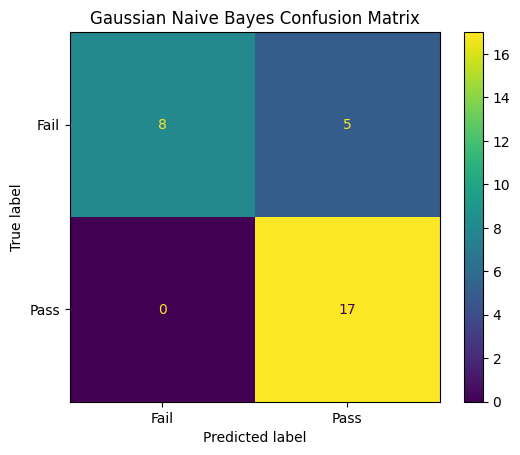

In [13]:
labels = ["Fail", "Pass"]
cm = confusion_matrix(y_test, y_pred, labels=labels)

ConfusionMatrixDisplay(cm, display_labels=labels).plot()
plt.title("Gaussian Naive Bayes Confusion Matrix")
plt.show()

## 14. Predict new students

In [50]:
new_students = pd.DataFrame({
    "StudyHours": [2, 5, 8],
    "AttendancePercent": [50, 70, 92]
})

pred = model.predict(new_students)
proba = model.predict_proba(new_students)

output = new_students.copy()
output["Prediction"] = pred

for i, c in enumerate(model.classes_):
    output[f"Probability_{c}"] = proba[:, i]

output

,StudyHours,AttendancePercent,Prediction,Probability_Fail,Probability_Pass
0,2,50,Fail,0.946139,0.053861
1,5,70,Pass,0.421875,0.578125
2,8,92,Pass,0.003661,0.996339


## Key idea

For every new student, GaussianNB calculates:

- How likely the values are under the Pass class.
- How likely the values are under the Fail class.
- Combines these with class priors.
- Selects the class with the larger posterior probability.
